# Pretrain A/B/C 비교 (비파괴)

`compare_pretrain_ab.py` 가 **호스트 `os.environ` 을 바꾸지 않습니다.**  
각 측정은 `pretrain_bench_core.isolated_env()` 안에서만 env override 를 적용하고, 끝나면 원래 값으로 복구합니다.

- **A (baseline)**: `MMFFRANDOM_FAST`, `MMFFRANDOM_WEIGHTED`, `PRETRAIN_AMP` 제거 → 기존 PyG `RandomView` 경로.
- **B (optimized)**: `MMFFRANDOM_FAST=1`, `PRETRAIN_AMP=bf16` → `FastRandomMMFFView` + autocast.
- **C (weighted, optional)**: `MMFFRANDOM_WEIGHTED=1`, `PRETRAIN_AMP=bf16`, `MMFF_WEIGHTS_PATH=<.pt>` → `WeightedMMFFView` + autocast. 가중치 `.pt` 는 아래 셀에서 자동 빌드.

가중치 소스 (`WEIGHT_SOURCE`):
- `"boltzmann"` — MoleculeNet `maxK_energy` 로 `softmax(-(E - Emin)/kT)`. 즉시 빌드 (수십초).
- `"qdf"` — QDF homolumo 체크포인트로 분자×슬롯 추론 → CSV → softmax. 한 번만 빌드해 두면 `.pt` 재사용. ESOL ~10분.

출력: `examples/sslgraph/bench/figs/pretrain_ab_<MMDD_HHMM>/`

  - `pretrain_ab_results.json` — wall / stage ms / resource summary 전부 (A/B/C)
  - `bars_pretrain_ab_*.png` — wall·CPU·XPU·RSS 막대 (값 라벨 박힘)
  - `bars_pretrain_stages_*.png` — data/views/fwd/bwd 단계 ms (값 라벨 박힘)
  - `timeseries_cpu_xpu_*.png` — A/B/C 각각 CPU·XPU 시계열 (0.5s 이동평균)

CPU/XPU 샘플링은 Windows 에서 QDF `QuantumDeepField_molecule/bench/sampler.py` (PDH) 를 동적 로드해 재사용합니다. QDF 트리가 없으면 psutil CPU-only 폴백.

In [3]:
import os
import shlex
import subprocess
import sys
from pathlib import Path

NB_DIR = Path.cwd()
if NB_DIR.name != "bench":
    NB_DIR = Path("examples/sslgraph/bench").resolve()
REPO_ROOT = NB_DIR.parents[2]
PY = Path(sys.executable)

# --- 사용자 조정 -------------------------------------------------
DATASET = "esol"
BATCH_SIZE = 400
WARMUP = 1
EPOCHS = 1
MAX_ITERS = 3        # 빠른 비교; 전체 epoch 측정은 0
INTERVAL = 0.1       # 리소스 샘플 간격 (초)

# 3-way (WEIGHTED) 옵션
COMPARE_MODE = "abc"          # "ab" (기존) 또는 "abc"
WEIGHT_SOURCE = "boltzmann"   # "boltzmann" 또는 "qdf"
WEIGHT_KT = 0.5               # softmax temperature (작을수록 mode collapse)
WEIGHT_SCORE_EXPR = "-(lumo - homo)"   # QDF 전용: gap 클수록 가중치 ↑
# -----------------------------------------------------------------

WEIGHTS_PT = REPO_ROOT / "dataset" / f"{DATASET}_mmff_weights_{WEIGHT_SOURCE}.pt"
QDF_CSV    = REPO_ROOT / "dataset" / f"{DATASET}_qdf_mmff_preds.csv"

def _run(cmd, **kw):
    print("$", " ".join(shlex.quote(str(c)) for c in cmd))
    return subprocess.run([str(c) for c in cmd], cwd=str(REPO_ROOT),
                          text=True, encoding="utf-8", errors="replace",
                          check=True, **kw)

# ---- (C run 사전 준비) 가중치 .pt 가 없으면 빌드 ----------------
if COMPARE_MODE == "abc":
    if not WEIGHTS_PT.exists():
        if WEIGHT_SOURCE == "qdf":
            if not QDF_CSV.exists():
                print(f"[step] QDF homolumo CSV 빌드 (없음): {QDF_CSV}")
                _run([
                    PY, NB_DIR / "qdf_mmff_predict.py",
                    "--dataset", DATASET, "--batch-size", "16",
                    "--out", QDF_CSV,
                ])
            print(f"[step] qdf 가중치 .pt 빌드 → {WEIGHTS_PT}")
            _run([
                PY, NB_DIR / "compute_mmff_weights.py",
                "--dataset", DATASET, "--source", "qdf",
                "--pred-csv", QDF_CSV, "--kT", str(WEIGHT_KT),
                "--score-expr", WEIGHT_SCORE_EXPR, "--out", WEIGHTS_PT,
            ])
        else:
            print(f"[step] boltzmann 가중치 .pt 빌드 → {WEIGHTS_PT}")
            _run([
                PY, NB_DIR / "compute_mmff_weights.py",
                "--dataset", DATASET, "--source", "boltzmann",
                "--kT", str(WEIGHT_KT), "--out", WEIGHTS_PT,
            ])
    else:
        print(f"[step] 기존 가중치 재사용: {WEIGHTS_PT}")

# ---- compare_pretrain_ab.py 명령 구성 ---------------------------
cmd = [
    str(PY), str(NB_DIR / "compare_pretrain_ab.py"),
    "--dataset", DATASET,
    "--batch-size", str(BATCH_SIZE),
    "--warmup", str(WARMUP),
    "--epochs", str(EPOCHS),
    "--max-iters", str(MAX_ITERS),
    "--interval", str(INTERVAL),
]
if COMPARE_MODE == "abc":
    label = (f"weighted ({WEIGHT_SOURCE.upper()}/kT={WEIGHT_KT}, "
             f"bf16)")
    cmd += [
        "--c-label", label,
        "--c-set", "MMFFRANDOM_WEIGHTED=1",
        "--c-set", "PRETRAIN_AMP=bf16",
        "--c-set", f"MMFF_WEIGHTS_PATH={WEIGHTS_PT.as_posix()}",
    ]

print("$ " + " ".join(shlex.quote(c) for c in cmd))
print("cwd =", REPO_ROOT)

OUT_DIR = None
_run(cmd)

fig_root = NB_DIR / "figs"
dirs = sorted([p for p in fig_root.glob("pretrain_ab_*") if p.is_dir()],
              key=lambda p: p.stat().st_mtime, reverse=True)
OUT_DIR = dirs[0] if dirs else None
print("latest OUT_DIR:", OUT_DIR)

latest OUT_DIR: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_ab_0512_1846


OUT_DIR: c:\DGCL\3DGCL\examples\sslgraph\bench\figs\pretrain_ab_0512_1846
timestamp: 0512_1846
 A: 13.423s  cpu=90.5%  xpu=54.8%  peak_rss=6957MB
 B: 4.229s  cpu=96.2%  xpu=75.1%  peak_rss=7588MB
 C: 3.372s  cpu=94.9%  xpu=93.4%  peak_rss=8100MB  weights: 1128/1128 (esol_mmff_weights_boltzmann.pt)

speedup A/B wall = 3.17x
speedup A/C wall = 3.98x
ratio  B/C wall = 1.25x  (>1: C faster)


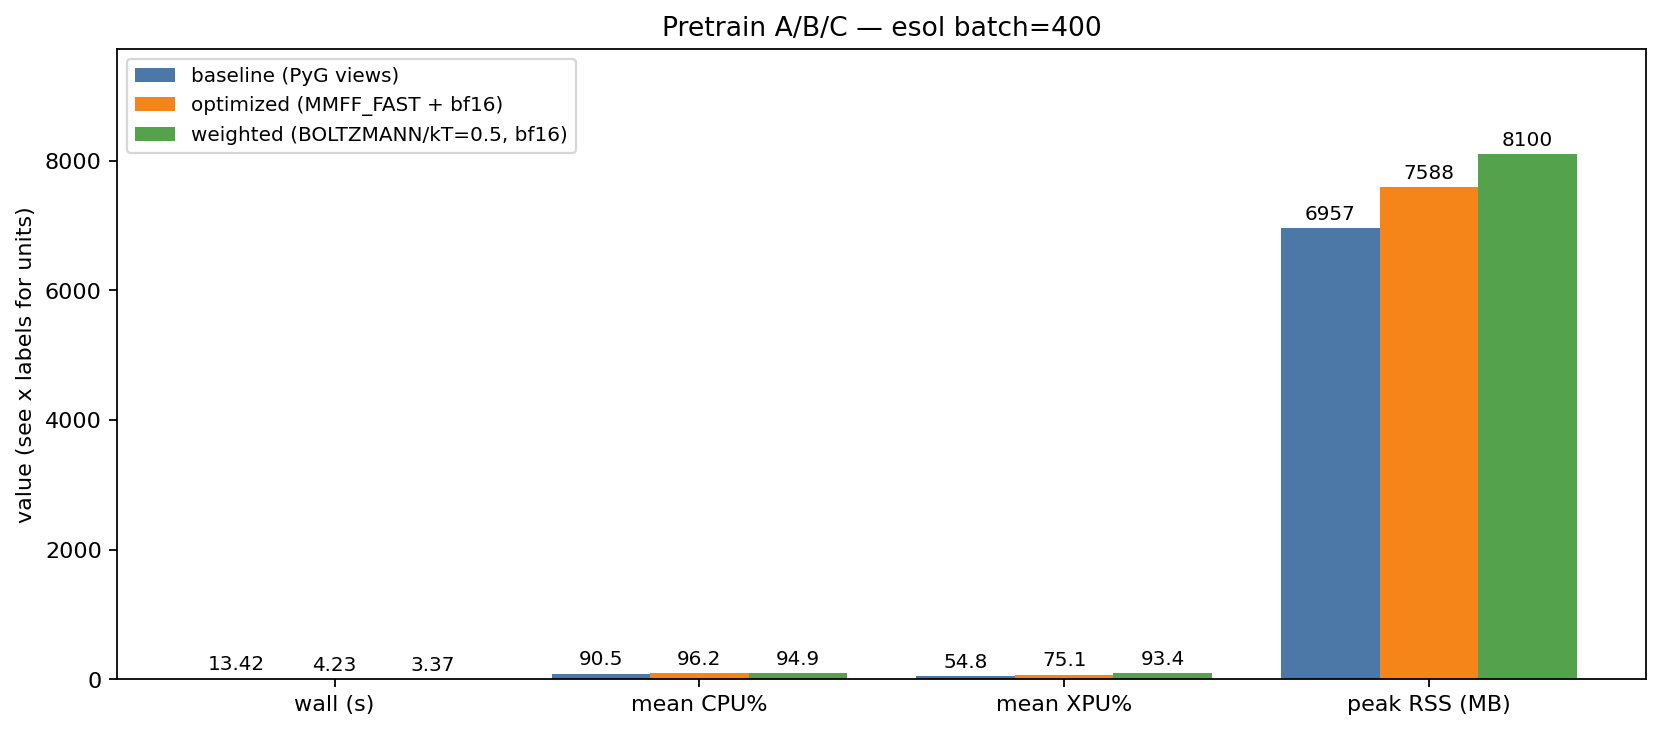

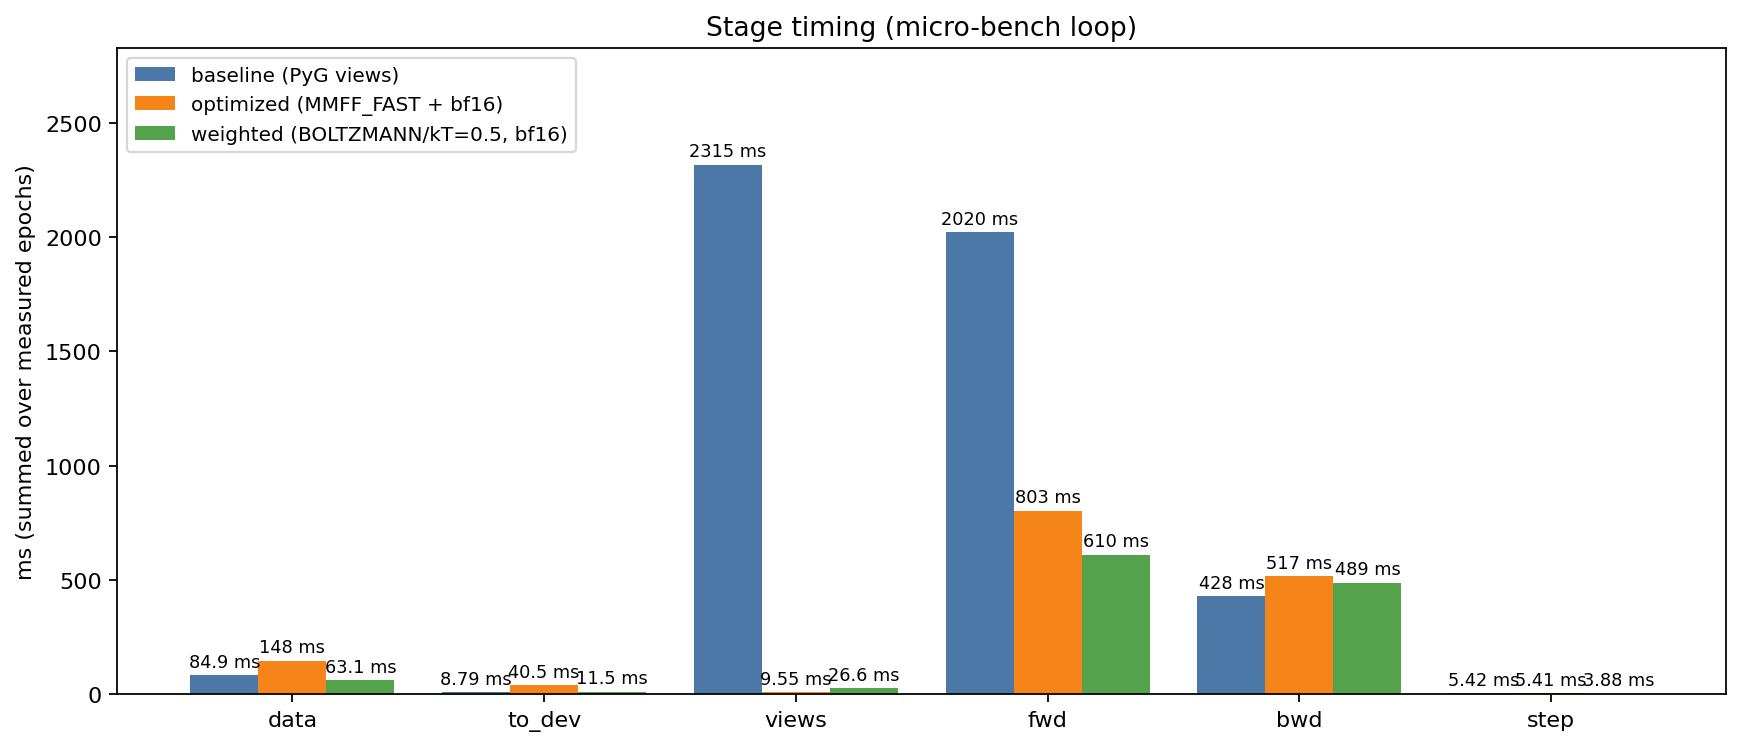

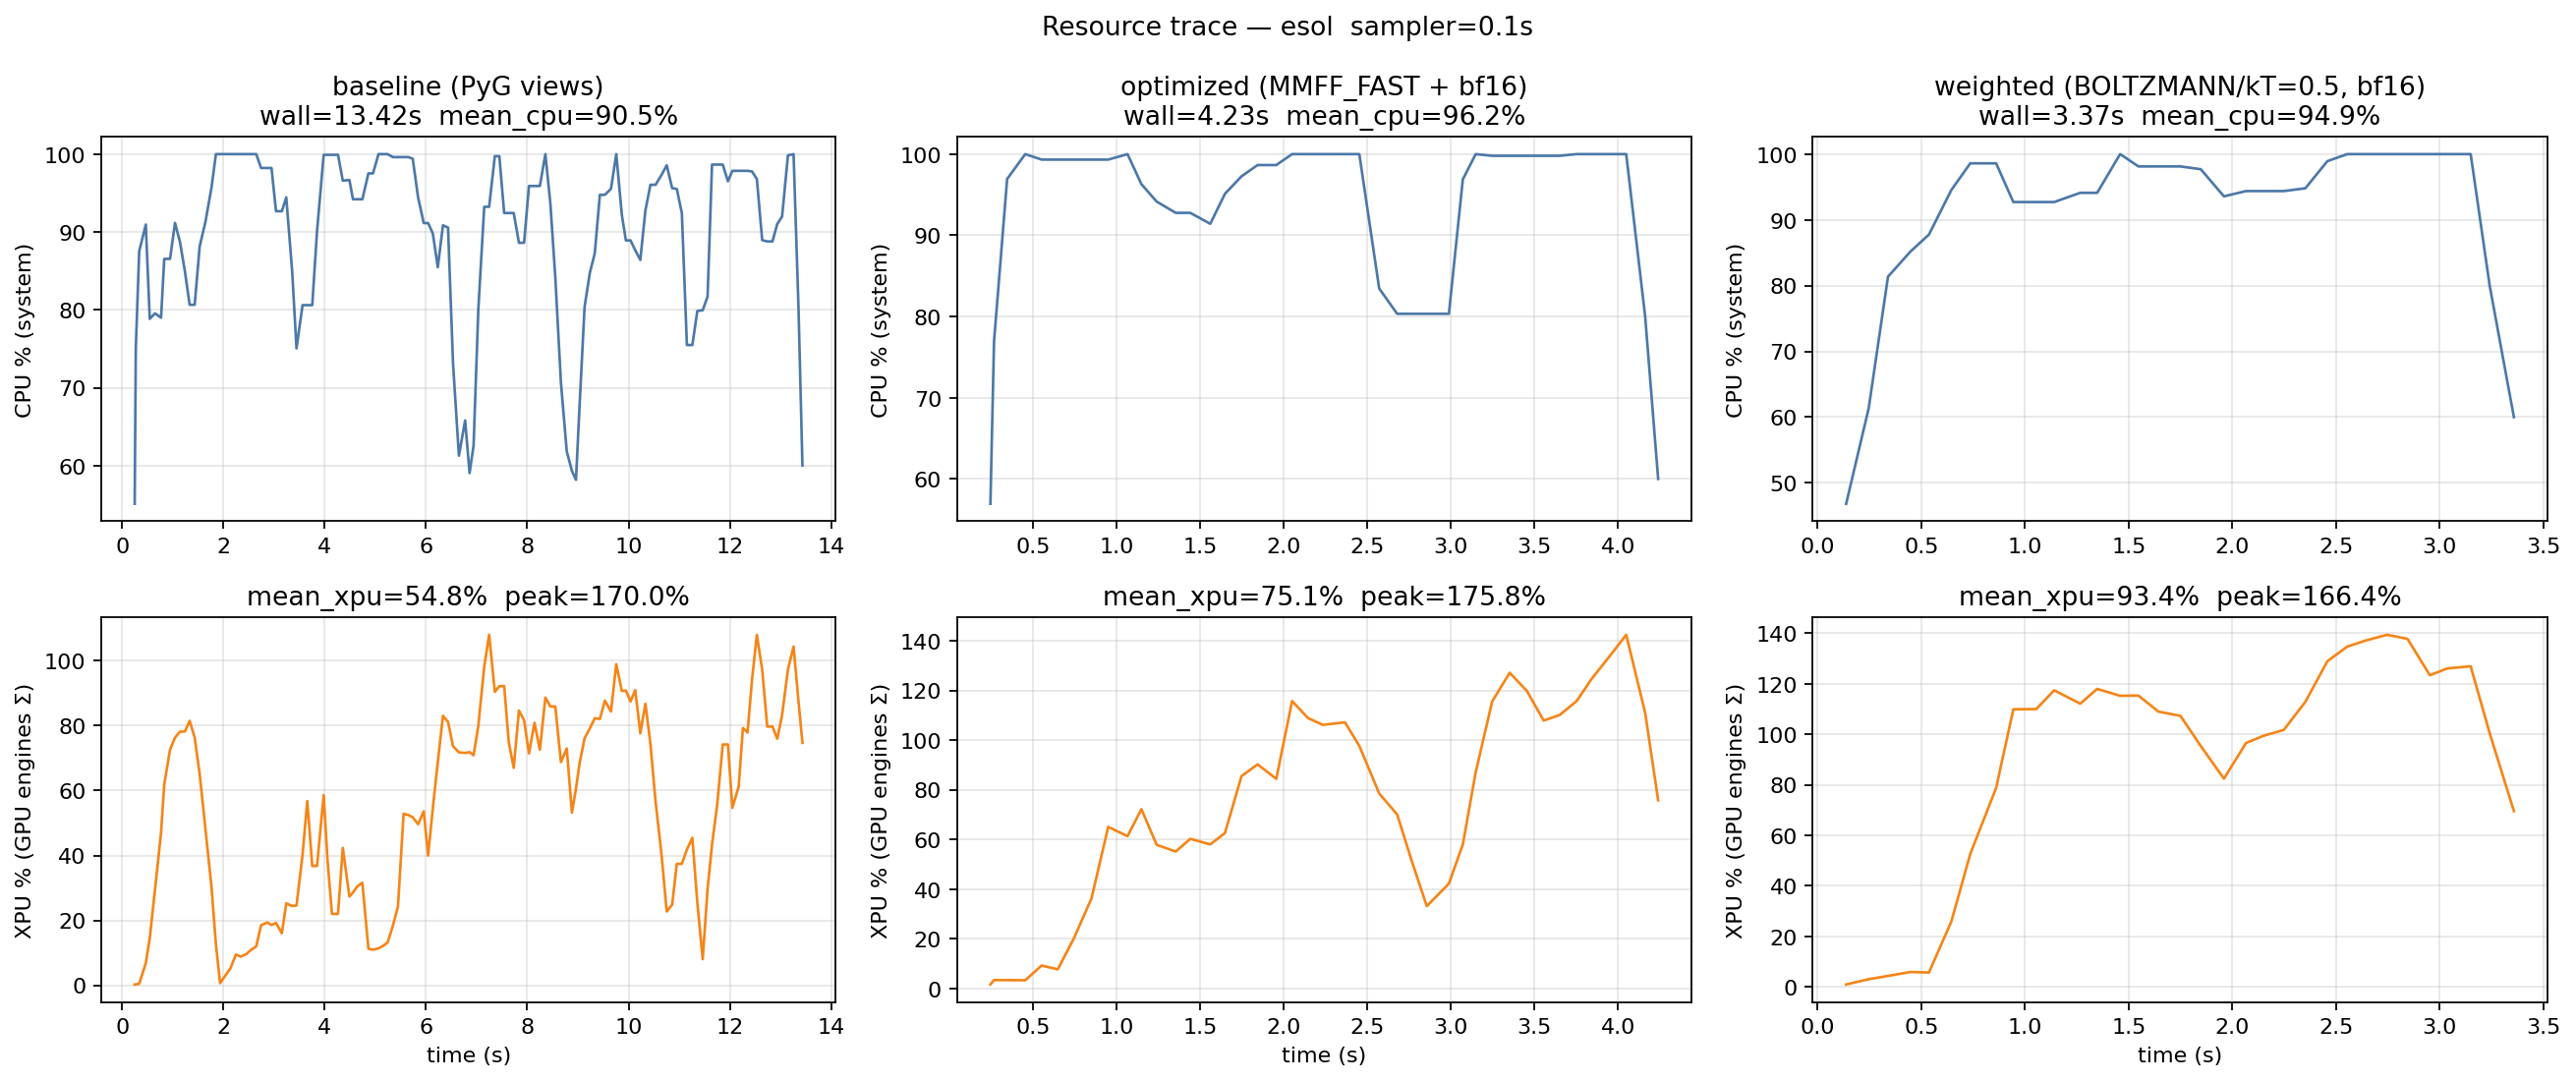

In [5]:
import json
from pathlib import Path
from IPython.display import Image, display

if "NB_DIR" not in dir():
    NB_DIR = Path.cwd()
    if NB_DIR.name != "bench":
        NB_DIR = Path("examples/sslgraph/bench").resolve()

fig_root = NB_DIR / "figs"
if "OUT_DIR" not in dir() or OUT_DIR is None:
    dirs = sorted([p for p in fig_root.glob("pretrain_ab_*") if p.is_dir()],
                  key=lambda p: p.stat().st_mtime, reverse=True)
    OUT_DIR = dirs[0] if dirs else None

if OUT_DIR is None or not OUT_DIR.is_dir():
    raise RuntimeError(
        "OUT_DIR 없음 — 위 셀을 먼저 실행하거나 figs/pretrain_ab_* 가 있는지 확인하세요."
    )

js = json.loads((OUT_DIR / "pretrain_ab_results.json").read_text(encoding="utf-8"))
ts = js["ts"]
print("OUT_DIR:", OUT_DIR)
print("timestamp:", ts)


def _row(label, summary, run):
    if summary is None:
        return
    wm = run.get("mmff_weights") if isinstance(run, dict) else None
    extra = ""
    if wm:
        extra = (f"  weights: {wm.get('n_attached','?')}/{wm.get('n_total','?')} "
                 f"({Path(wm.get('path','')).name})" if 'n_total' in wm else
                 f"  weights: {wm.get('error','?')}")
    print(f"{label:>2}: {summary['wall_s']:.3f}s  "
          f"cpu={summary['mean_cpu_pct']:.1f}%  "
          f"xpu={summary['mean_xpu_pct']:.1f}%  "
          f"peak_rss={summary['peak_rss_mb']:.0f}MB{extra}")


_row("A", js.get("summary_a"), js.get("run_a"))
_row("B", js.get("summary_b"), js.get("run_b"))
if js.get("summary_c") is not None:
    _row("C", js.get("summary_c"), js.get("run_c"))

wa = js["summary_a"]["wall_s"]
wb = js["summary_b"]["wall_s"]
print(f"\nspeedup A/B wall = {wa / max(wb, 1e-9):.2f}x")
if js.get("summary_c") is not None:
    wc = js["summary_c"]["wall_s"]
    print(f"speedup A/C wall = {wa / max(wc, 1e-9):.2f}x")
    print(f"ratio  B/C wall = {wb / max(wc, 1e-9):.2f}x  (>1: C faster)")

for name in (
    f"bars_pretrain_ab_{ts}.png",
    f"bars_pretrain_stages_{ts}.png",
    f"timeseries_cpu_xpu_{ts}.png",
):
    p = OUT_DIR / name
    if p.is_file():
        display(Image(filename=str(p)))
    else:
        print("missing:", p)